In [1]:
%%writefile module/test1.py
import streamlit as st
import pandas as pd
import numpy as np
import requests as req
import folium
import streamlit_folium as sf
from streamlit_option_menu import option_menu
from streamlit_lottie import st_lottie
import matplotlib.pyplot as plt
from folium.plugins import MiniMap, Fullscreen, HeatMap
import json
import requests
from folium.features import DivIcon
st.set_page_config(
    layout='wide',
    page_title='Smoke',
    page_icon='🚭'
)

# ====[사이드바] 부분====
with st.sidebar:
    
    col1, col2 = st.columns([1,5])

    # 로고 부분(좌측)
    with col1 :
        st.image('https://cdn-icons-png.flaticon.com/512/2103/2103633.png', width=50)
    # 텍스트 부분(우측)
    with col2 :
        st.markdown('서울시 흡연율')

    # 사이드바에 option_menu UI 배치
    option_menu_side =  option_menu(
        menu_title='메뉴 선택',
        menu_icon='cast',
        options=['흡연율 현황', '데이터 분석', '요약'],
        icons=['speedometer2', 'bar-chart-line', 'gear'],
        default_index=0,
        styles={
            # container : 메뉴 탭들을 감싸는 전체 공간
             # padding : 요소 내부의 여백(현재는 0으로 여백이 없으며 !important는 해당 스타일을 우선 적용)
             # background-color : 배경색(컬러 GEX코드 값으로 설정 가능)
            'container': {'padding': '10!important', 'background-color' : '#fafafa'},
            'icon' : {'color': 'red', 'font-size' : '18px'},
            # nav-link : 메뉴 탭 내부 관련 설정
             # text-align : 텍스트 정렬
             # --hover-color : 메뉴에 마우스 오버시 변경되는 색상(#eee는 옅은 회색)
            'nav-link': {'font-size':'16px', 'text-align': 'left', 
                         'margin':'0px','--hover-color':'#eee'},
            # nav-link-selected : 메뉴 탭이 선택되었을 때의 설정(#02ab21는 진한 녹색) 
            'nav-link-selected': {'background-color': 'black'}
        }

    )
    st.info(f'현재 접속 : {option_menu_side} 모드')

@st.cache_data
def load_lottie_json(url):
    res = req.get(url)
    # status_code : <Response [200]> 에서 []안의 수치값 확인

    if res.status_code != 200:
        return st.error('통신 에러 발생')
    return res.json()



# ================ 메인화면 ==================
# 1) 대시보드 선택 시
if option_menu_side == '흡연율 현황':
    lottie1 = load_lottie_json(
    "https://lottie.host/b2039d5e-ab26-428a-8a65-839fafabfbf7/7rs4mysdZt.json"
    )
    with st.container():
        col1, col2 = st.columns([3, 2])

    # 텍스트 파트(좌측)
    with col1 :
        st.title('흡연율 현황')


        
        # --------------------------------------------------------------------------------
        # 1. 데이터 준비 (작성자님의 데이터프레임이 있다고 가정)
        # --------------------------------------------------------------------------------
        rate_df = pd.read_csv('module/data/rate.csv', encoding='utf-8')

        # 2. 서울시 지도 데이터(GeoJSON) 불러오기 (GitHub에서 실시간 로딩)
        # --------------------------------------------------------------------------------
        # 서울시 자치구 경계 좌표가 들어있는 파일 주소입니다. (가장 많이 쓰는 소스)
        geo_url = 'https://raw.githubusercontent.com/southkorea/seoul-maps/master/kostat/2013/json/seoul_municipalities_geo_simple.json'
        response = requests.get(geo_url)
        seoul_geo = response.json()
        
        # 1. 지도에 라벨(구이름) 달기위한 함수
        def make_text(text, color='white', size=11):  # 기본값을 white, 11로 변경
            return DivIcon(
                icon_size=(100, 20),
                icon_anchor=(50, 10),
                html=f'''
                    <div style="
                        font-size: {size}pt;
                        font-weight: 900;
                        color: {color};
                        
                        /* 핵심: 그림자 대신 4방향 테두리를 줘서 글자를 선명하게 만듦 */
                        text-shadow: -1px -1px 0 #000, 
                                      1px -1px 0 #000, 
                                     -1px  1px 0 #000, 
                                      1px  1px 0 #000;
                                      
                        text-align: center;
                        white-space: nowrap; /* 글자 줄바꿈 금지 (한 줄로 나오게) */
                    ">
                        {text}
                    </div>
                '''
            )
        # --------------------------------------------------------------------------------
        # 3. Folium 지도 그리기 (Choropleth)
        # --------------------------------------------------------------------------------
        # (1) 기본 지도 생성 (서울 시청 중심 좌표)
        m = folium.Map(
            location=[37.5665, 126.9780], 
            zoom_start=11, 
            tiles='cartodbpositron' # 깔끔한 배경 스타일 (OpenStreetMap보다 분석용으로 좋음)
        )
        rate_df = pd.read_csv('module/data/rate.csv', encoding='utf-8')
        rate_df[['region', 'rate']]
        # (2) 단계구분도(색칠) 레이어 추가
        folium.Choropleth(
            geo_data=seoul_geo,             # 지도 경계 데이터
            data=rate_df,                        # 분석할 데이터프레임
            columns=['region', 'rate'], # [지역명 컬럼, 수치 컬럼]
            key_on='feature.properties.name', # GeoJSON 파일 안에 있는 지역명 키 값 (이거 건드리면 안됨!)
            fill_color='YlOrRd',            # 색상 (Yellow-Orange-Red: 빨갈수록 높음)
            fill_opacity=0.7,               # 투명도
            line_opacity=0.2,               # 경계선 투명도
            legend_name='현재 흡연율 (%)'     # 범례 이름
        ).add_to(m)

        
        # 2. 반복문으로 25개 구 한 번에 추가하기
        # seoul_geo['features'] 자체가 일종의 리스트입니다.
        for feature in seoul_geo['features']:
            # 이름 꺼내기
            name = feature['properties']['name']
            
            # 좌표 계산 (seoul_geo데이터에 있는 구별 위도와 경도 평균값)
            coords = np.array(feature['geometry']['coordinates'][0])
            center_lat = coords[:, 1].mean()
            center_lon = coords[:, 0].mean()
            
            # 지도에 추가 (여기서 함수 사용!)
            folium.Marker(
                location=[center_lat, center_lon],
                icon=make_text(name) # <-- "이름(name)으로 라벨 만들어줘"
            ).add_to(m)
                
        
        # --------------------------------------------------------------------------------
        # 4. Streamlit 화면에 띄우기
        # --------------------------------------------------------------------------------
        st.title("🗺️ 서울시 자치구별 흡연율 지도")
        sf.st_folium(m, width=700)







        
        green_df = pd.read_csv('module/data/green.csv', encoding='utf-8')
        rate_df = pd.read_csv('module/data/rate.csv', encoding='utf-8')
        test_df = pd.concat([rate_df[['region', 'rate']],green_df[['green_rate']]], axis = 1, join='inner')


        fig, ax = plt.subplots()
        ax.scatter(test_df['green_rate'], test_df['rate'], color='blue', alpha=1.0)
        ax.set_xlabel('green')
        ax.set_ylabel('smoke')

        st.pyplot(fig)

    # 애니메이션 파트 (우측)
    with col2:
        if lottie1 :
            # height : 애니메이션 높이(지정하지 않으면 원본 비율로 출력)
            # weight : 애니메이션 너비(지정하지 않으면 할당된 공간에 맞춰 출력)
            
            st_lottie(lottie1, height=300, key='a')

    
    
elif option_menu_side == '데이터 분석':
    st.title('데이터 분석')
    
    option_menu_main = option_menu(
        menu_title=None,
        options=["요약 보기",'123123', '😎'],
        icons=['card-checklist', 'activity', 'cloud-download'],
        default_index=0,
        orientation='horizontal',  # 메뉴 탭 출력 형태를 수평으로 설정(수직은 vertical)
            styles={
        "container": {"padding": "0!important", "background-color": "#fafafa"},
        "icon": {"color": "orange", "font-size": "25px"}, 
        "nav-link": {"font-size": "20px", "text-align": "center", "margin":"0px", "--hover-color": "#eee"},
        "nav-link-selected": {"background-color": "green"},
    }
    )
    '---'
    # 메인 메뉴 선택에 따른 출력 내용 변경
    if option_menu_main == "요약 보기" :
        pass
        

    elif option_menu_main == '123123':
        st.subheader('실시간 접속 현황')
        # 더미 차트 생성
        chart_data = pd.DataFrame(np.random.randn(20,3),
                                 columns=['A','B','C']
                                 )
        st.line_chart(chart_data)
    elif option_menu_main == '😎':
        pass

elif option_menu_side == '요약':
    pass

Overwriting module/test1.py


Text(0, 0.5, 'smoke')

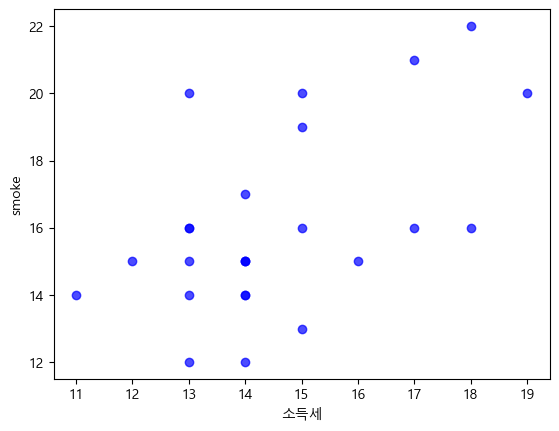

In [94]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
final_df = pd.read_excel('module/data/final_df.xlsx')

import matplotlib.pyplot as plt

# 폰트를 맑은 고딕으로 설정해서 한글깨짐 방지
plt.rc('font', family='Malgun Gothic')
# scatter : 산점도 그래프 출력(두 특성간의 상관관계를 파악하기 위한 차트)
plt.scatter(final_df['고위험음주'], final_df['흡연'], # x,y축
           color='blue',alpha=0.7); # 색상, 투먕도 설정

plt.xlabel('소득세')
plt.ylabel('smoke')


In [63]:
import streamlit as st
import pandas as pd
import folium
from streamlit_folium import st_folium
import json
import requests

# --------------------------------------------------------------------------------
# 1. 데이터 준비 (작성자님의 데이터프레임이 있다고 가정)
# --------------------------------------------------------------------------------

# --------------------------------------------------------------------------------
# 2. 서울시 지도 데이터(GeoJSON) 불러오기 (GitHub에서 실시간 로딩)
# --------------------------------------------------------------------------------
# 서울시 자치구 경계 좌표가 들어있는 파일 주소
geo_url = 'https://raw.githubusercontent.com/southkorea/seoul-maps/master/kostat/2013/json/seoul_municipalities_geo_simple.json'
response = requests.get(geo_url)
seoul_geo = response.json()


# --------------------------------------------------------------------------------
# 3. Folium 지도 그리기 (Choropleth)
# --------------------------------------------------------------------------------
# (1) 기본 지도 생성 (서울 시청 중심 좌표)
m = folium.Map(
    location=[37.5665, 126.9780], 
    zoom_start=11, 
    tiles='cartodbpositron' # 깔끔한 배경 스타일 (OpenStreetMap보다 분석용으로 좋음)
)
rate_df = pd.read_csv('module/data/rate.csv', encoding='utf-8')
rate_df[['region', 'rate']]
# (2) 단계구분도(색칠) 레이어 추가
folium.Choropleth(
    geo_data=seoul_geo,             # 지도 경계 데이터
    data=rate_df,                        # 분석할 데이터프레임
    columns=['자치구', '현재흡연율'], # [지역명 컬럼, 수치 컬럼]
    key_on='feature.properties.name', # GeoJSON 파일 안에 있는 지역명 키 값 (이거 건드리면 안됨!)
    fill_color='YlOrRd',            # 색상 (Yellow-Orange-Red: 빨갈수록 높음)
    fill_opacity=0.7,               # 투명도
    line_opacity=0.2,               # 경계선 투명도
    legend_name='현재 흡연율 (%)'     # 범례 이름
).add_to(m)

# --------------------------------------------------------------------------------
# 4. Streamlit 화면에 띄우기
# --------------------------------------------------------------------------------
st.title("🗺️ 서울시 자치구별 흡연율 지도")
st_folium(m, width=700)

2026-02-05 19:18:54.532 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


ValueError: Length mismatch: Expected 5 rows, received array of length 25

In [82]:
import pandas as pd
final_df = pd.read_excel('module/data/final_df.xlsx')

print(final_df)
final_df['비만']

      명칭  흡연        녹지  도보생활권공원  스트레스  우울감      금연치료센터  주거면적       1인가구  음주  \
0    강남구  12  3.479541     6.60    26    8   59.209287  33.0  25.939851  63   
1    강동구  15  1.275268     4.36    21    8   37.530769  26.4  25.234065  62   
2    강북구  20  0.491179     7.36    33    6   35.966530  27.2  29.087275  55   
3    강서구  16  2.072873     6.28    32    9   33.802554  26.3  29.424671  54   
4    관악구  19  0.528017     3.97    29   10   35.997422  25.4  36.769335  58   
5    광진구  17  0.876146     3.88    29    7   37.654799  27.2  31.498821  63   
6    구로구  16  1.787124     4.05    26    6   36.324384  27.9  26.763524  61   
7    금천구  22  1.871926     2.36    30   11   37.751100  27.0  32.340543  59   
8    노원구  15  1.394846     3.82    25    6   33.791555  26.0  24.622500  63   
9    도봉구  20  0.901226     3.67    28   10   30.669991  27.8  25.028870  63   
10  동대문구  16  1.244465     2.95    20    3   38.082867  27.5  31.037397  63   
11   동작구  14  0.708150     5.97    29    9   35.1251

0     25
1     30
2     37
3     31
4     33
5     32
6     37
7     36
8     31
9     30
10    35
11    33
12    34
13    31
14    26
15    29
16    32
17    28
18    31
19    29
20    25
21    31
22    27
23    27
24    34
Name: 비만, dtype: int64